In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load decision events data
decision_df = pd.read_csv(r"data/face_decision_events_last_7_days_20250905_110624.csv")

# Convert timestamp
decision_df['source_timestamp'] = pd.to_datetime(decision_df['source_timestamp'], errors='coerce')

# Summary statistics
mahal_summary = decision_df['mahalanobis'].describe()
print(mahal_summary)


count    33330.000000
mean         0.738766
std          0.295571
min          0.200016
25%          0.440875
50%          0.916035
75%          1.000000
max          1.000000
Name: mahalanobis, dtype: float64


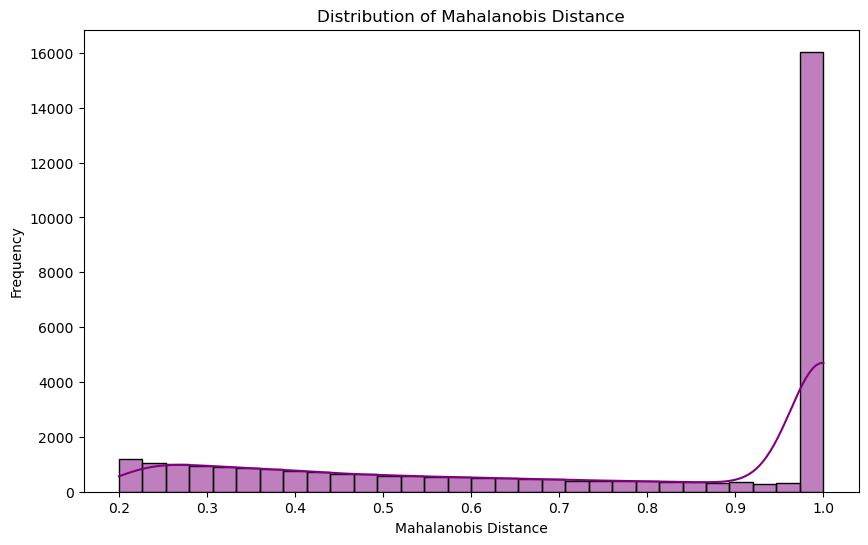

In [3]:
plt.figure(figsize=(10,6))
sns.histplot(decision_df['mahalanobis'], bins=30, kde=True, color="purple")
plt.title("Distribution of Mahalanobis Distance")
plt.xlabel("Mahalanobis Distance")
plt.ylabel("Frequency")
plt.show()


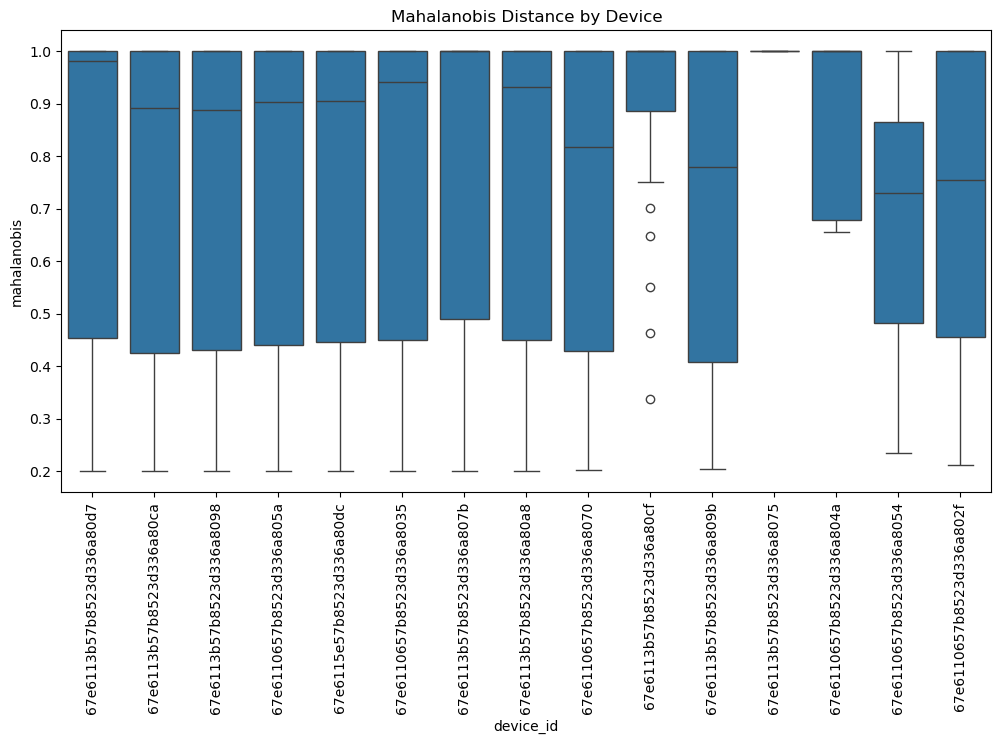

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='device_id', y='mahalanobis', data=decision_df)
plt.xticks(rotation=90)
plt.title("Mahalanobis Distance by Device")
plt.show()


In [18]:
hourly_mahal

,date,hour,device_id,mahalanobis,date_hour
0,2025-08-29,15,67e6110657b8523d336a8035,0.738515,2025-09-05 09:00:00
1,2025-08-29,15,67e6110657b8523d336a805a,0.810197,2025-09-05 09:00:00
2,2025-08-29,15,67e6110657b8523d336a8070,0.800432,2025-09-05 09:00:00
3,2025-08-29,15,67e6113b57b8523d336a807b,1.000000,2025-09-05 09:00:00
4,2025-08-29,15,67e6113b57b8523d336a8098,0.762522,2025-09-05 09:00:00
...,...,...,...,...,...
817,2025-09-05,9,67e6113b57b8523d336a8098,0.670607,2025-09-05 09:00:00
818,2025-09-05,9,67e6113b57b8523d336a80a8,0.711943,2025-09-05 09:00:00
819,2025-09-05,9,67e6113b57b8523d336a80ca,0.743454,2025-09-05 09:00:00
820,2025-09-05,9,67e6113b57b8523d336a80d7,0.737271,2025-09-05 09:00:00


In [21]:
import pandas as pd
import plotly.express as px

# Ensure timestamp is datetime
decision_df['log_timestamp'] = pd.to_datetime(decision_df['log_timestamp'])

# Extract hour
decision_df['hour'] = decision_df['log_timestamp'].dt.hour
decision_df['date'] = decision_df['log_timestamp'].dt.date

decision_df.fillna({'mahalanobis': 0}, inplace=True)

# Group by device and hour, calculate mean
hourly_mahal = (decision_df
                .groupby(['date','hour','device_id'])['mahalanobis']
                .mean()
                .reset_index())

hourly_mahal['date_hour'] = (
        pd.to_datetime(hourly_mahal['date'].astype(str))
        + (pd.to_timedelta(hourly_mahal['hour'], unit='h'))
    )

# Plot with Plotly
fig = px.line(hourly_mahal,
              x="date_hour",
              y="mahalanobis",
              color="device_id",
              markers=True,
              title="Hourly Average Mahalanobis Distance per Device")

fig.update_layout(xaxis_title="Hour",
                  yaxis_title="Average Mahalanobis",
                  legend_title="Device ID",)

fig.show()


              best_score  score_max  mahalanobis  norm_entropy
best_score      1.000000   1.000000     0.103055     -0.299952
score_max       1.000000   1.000000     0.103001     -0.299920
mahalanobis     0.103055   0.103001     1.000000     -0.184440
norm_entropy   -0.299952  -0.299920    -0.184440      1.000000


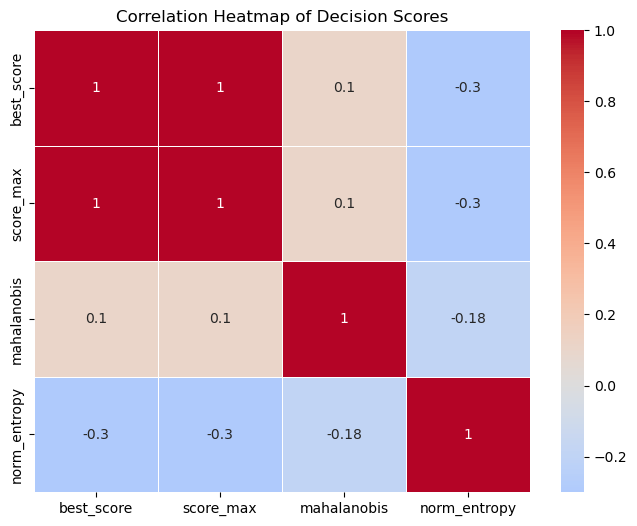

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select score columns
score_cols = ['best_score', 'score_max', 'mahalanobis', 'norm_entropy']

# Compute correlation matrix
corr_matrix = decision_df[score_cols].corr()
print(corr_matrix)


plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Decision Scores")
plt.show()

